In [32]:
from functools import partial
import os
os.environ["OPENBLAS_NUM_THREADS"] = "12"

import sax
from simphony.libraries import siepic
from ctypes import Array
import numpy as np, matplotlib.pyplot as plt
from pyparsing import Union
from simphony.circuit import Circuit
from simphony.simulation import SampleModeSimulation
from simphony.simulation.sample_mode import SampleModeSimulationParameters, SampleModeSimulation
from simphony.circuit.components import SampleModeComponent
from simphony.signals import SampleModeOpticalSignal
import jax
import jax.numpy as jnp
from commpy.filters import rrcosfilter
from scipy.signal import upfirdn
from scipy.integrate import solve_ivp
N = 5000
def minmax(u):
    return (u - u.min())/(u.max() - u.min())
key = jax.random.PRNGKey(0)
key2 = jax.random.PRNGKey(1)
sigma, rho, beta = 10.0, 28.0, 8/3

def lorenz(t, xyz):
    x, y, z = xyz
    return [sigma*(y - x), x*(rho - z) - y, x*y - beta*z]

N_coarse = N
dtt = 0.05
upsample = 1

T = dtt * (N_coarse - 1)

dt_fine = dtt / upsample
t_fine = np.arange(0.0, T + 1e-12, dt_fine)

sol_fine = solve_ivp(
    lorenz, (0.0, T), (0., 1., 1.05),
    method="RK45", max_step=dt_fine, t_eval=t_fine
)
x_f, y_f, z_f = sol_fine.y

signal  = minmax(x_f)
signal2 = minmax(y_f)
y       = minmax(z_f)
combined_sig = signal + signal2
combined_sig = minmax(combined_sig)*jnp.pi
def rrc_shape(symbols, h, sps):
    x = upfirdn(h.astype(np.float32), np.asarray(symbols, np.float32), up=sps)
    d = (len(h) - 1) // 2
    return jnp.asarray(x[d:d + len(symbols)*sps], dtype=jnp.float32)
sps = 50
beta = 0.5
span = 4
_, h = rrcosfilter(span*sps+1, beta, 1.0, sps)
phase_wave1 = rrc_shape(combined_sig,h, sps)


def GM(wl: Union[float, Array] = 1.55):
    def load_sdict_npz(fname):
        d = np.load(fname)
        wls = d["wavelengths"]
        S = {}
        for k in d.files:
            if k == "wavelengths": continue
            # keys like "S_out3_in5"
            _, to_p, from_p = k.split("_", 2)
            S[(to_p, from_p)] = np.squeeze(d[k])
        return wls, S
    w_i, Sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")
    return Sp


class StreamingCombSourceTime(SampleModeComponent):
    optical_ports = ["o0"]

    def __init__(self, base_wavelengths, scale=1.0):
        bw = jnp.asarray(base_wavelengths, jnp.float32).reshape(-1)
        self.base  = bw
        self.M     = int(bw.shape[0])
        self.scale = jnp.float32(scale)

    def sample_mode_initial_state(self, simulation_parameters):
        phi = jnp.zeros((self.M,), jnp.float32)
        t_idx = jnp.int32(0)
        return (phi, t_idx)

    @partial(jax.jit, static_argnums=(0,))
    def sample_mode_step(self, inputs, state, simulation_parameters):
        phi, t_idx = state
        A = (self.scale * jnp.exp(1j * phi).astype(jnp.complex64))[:, None]
        wls = self.base.astype(jnp.float32)
        out = {"o0": SampleModeOpticalSignal(amplitude=A, wavelength=wls)}
        return out, (phi, t_idx + jnp.int32(1))
    
class OpticalModulatorTime(SampleModeComponent):
    optical_ports = ["o0", "o1"]

    def __init__(self, *, length=1.0, operating_wl=1.55e-6, effective_index=2.4,
                 group_index=4.2, mod_signal=0.0):
        self.length = float(length)
        self.operating_wl = float(operating_wl)
        self.effective_index = float(effective_index)
        self.group_index = float(group_index)
        self.mod_signal = jnp.asarray(mod_signal)

    def sample_mode_initial_state(self, simulation_parameters):
        return jnp.int32(0)

    def sample_mode_step(self, inputs, state, simulation_parameters):
        a0 = inputs["o0"].amplitude  # forward field (W,M)
        a1 = inputs["o1"].amplitude  # reverse field (if any)
        lam = inputs["o0"].wavelength

        if a0.ndim == 1: a0 = a0[:, None]
        if a1.ndim == 1: a1 = a1[:, None]
        dtype = a0.dtype
        

        phase_t = self.mod_signal[state]
        

        coeff = jnp.exp(1j * (phase_t)).astype(dtype)
        out0 = SampleModeOpticalSignal(jnp.zeros_like(a1), lam)
        out1 = SampleModeOpticalSignal(a0 * coeff, lam)

        return {"o0": out0, "o1": out1}, state + 1

netlist = {
    "instances": {
        "laser1":"laser1",
        "wg1":"waveguide",
        "gm":"GM",
        "wgmzi1":"waveguide",
        "wgmzi2":"waveguide",
        "pm1":"phase_mod",
        "y2":"y_branch",
        "y3":"y_branch",
        
    },
       
    "connections": {
        # "laser1,o0":"wg1,o0"
        "laser1,o0":"y2,port_1",
        "y3,port_1":"wg1,o0",
        "wg1,o1": "gm,in0",
        "y2,port_2": "wgmzi1,o0",
        "y2,port_3": "wgmzi2,o0",
        "wgmzi1,o1":"pm1,o0",
        "pm1,o1":"y3,port_2",
        "wgmzi2,o1":"y3,port_3",
       
    },
    "ports": {
        "o0": "wg1, o1",
        "o1": "gm,out1",
        "o2": "gm,out2",
        "o3": "gm,out3",
        "o4": "gm,out4",
        "o5": "gm,out5",
    }
}

models = {
    "waveguide": siepic.waveguide,
    "laser1": StreamingCombSourceTime,
    "GM": GM,
    "y_branch": siepic.y_branch,
    "phase_mod": OpticalModulatorTime
}

dt = 1e-14
t = jnp.arange(0, 100000)*dt
print(len(t))
settings = {
    "laser1": {
    "base_wavelengths": jnp.array([1.53e-6,1.58e-6], jnp.float32),
    "scale":jnp.sqrt(7.0),
    },
    
    "wg1":{
        "length":366,
        "max_order":80
    },
    "pm1":{
        "mod_signal": phase_wave1,
    },
    "gm":{
        "max_order":130
        },
}

circuit = Circuit(netlist=netlist, models=models)
sim = SampleModeSimulation(circuit = circuit)
simulation_parameters = SampleModeSimulationParameters(
    optical_baseband_wavelengths=jnp.array([1.53e-6,1.57e-6], jnp.float32),
    num_time_steps=int(len(t)), sampling_period=dt)

results50 = sim.run(simulation_parameters=simulation_parameters, settings=settings)
jax.block_until_ready(results50)
#20 minutes using just one max_order_model

100000
Initial state for laser1 computed
Initial state for wg1 computed
Initial state for gm computed
Initial state for wgmzi1 computed
Initial state for wgmzi2 computed
Initial state for pm1 computed
Initial state for y2 computed
Initial state for y3 computed
Initial state for _optical_termination0 computed
Initial state for _optical_termination1 computed
Initial state for _optical_termination2 computed
Initial state for _optical_termination3 computed
Initial state for _optical_termination4 computed
Initial state for _optical_termination5 computed
Initial state for _optical_termination6 computed
Initial state for _optical_termination7 computed
Initial state for _optical_termination8 computed
Initial state for _optical_termination9 computed
Initial state for _optical_termination10 computed
Initial state for _optical_termination11 computed
Initial state for _optical_termination12 computed
Initial state for _optical_termination13 computed
Initial state for _optical_termination14 computed

{'o0': {'input': SampleModeOpticalSignal(amplitude=Array([[[0.+0.j],
          [0.+0.j]],
  
         [[0.+0.j],
          [0.+0.j]],
  
         [[0.+0.j],
          [0.+0.j]],
  
         ...,
  
         [[0.+0.j],
          [0.+0.j]],
  
         [[0.+0.j],
          [0.+0.j]],
  
         [[0.+0.j],
          [0.+0.j]]], dtype=complex128), wavelength=Array([1.53e-06, 1.57e-06], dtype=float32)),
  'output': SampleModeOpticalSignal(amplitude=Array([[[ 0.        +0.j        ],
          [ 0.        +0.j        ]],
  
         [[ 0.        +0.j        ],
          [ 0.        +0.j        ]],
  
         [[ 0.        +0.j        ],
          [ 0.        +0.j        ]],
  
         ...,
  
         [[-0.2040323 -1.26161939j],
          [ 0.10263529+1.35152918j]],
  
         [[-0.20395583-1.25991037j],
          [-0.00122875+1.35206934j]],
  
         [[-0.20326998-1.25909428j],
          [-0.1056624 +1.3444895j ]]], dtype=complex128), wavelength=Array([1.53e-06, 1.57e-06], dtype=float3

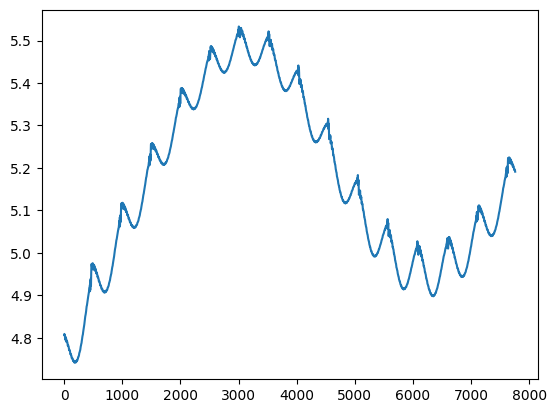

In [ ]:
loaded = np.load("results512.npz", allow_pickle=True)["results"].item()

arr = loaded["o0"]["output"].amplitude
plt.plot(np.abs(arr[7240:15000, 0, 0])**2)
plt.show()


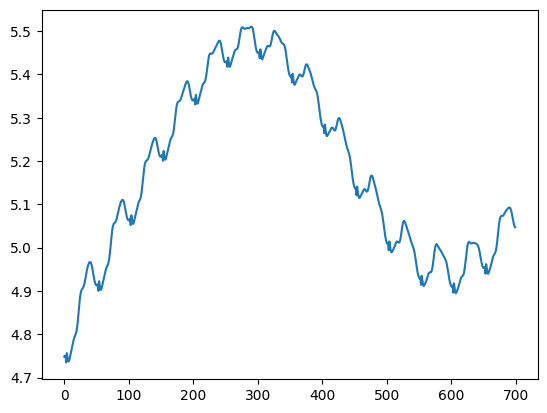

In [ ]:
loaded = np.load("results50.npz", allow_pickle=True)["results"].item()

arr = loaded["o0"]["output"].amplitude
plt.plot(np.abs(arr[1200:1900, 0, 0])**2)
plt.show()


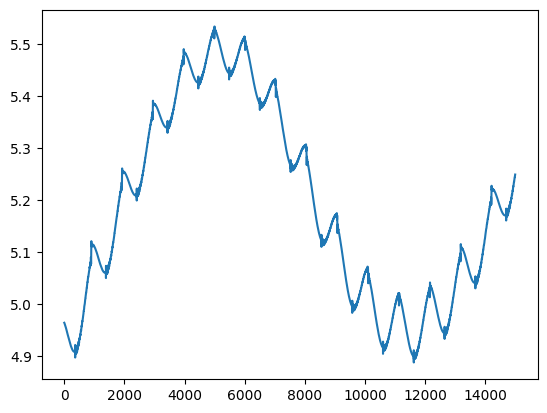

In [ ]:
loaded = np.load("results1024.npz", allow_pickle=True)["results"].item()

arr = loaded["o0"]["output"].amplitude
plt.plot(np.abs(arr[15000:30000, 0, 0])**2)
plt.show()

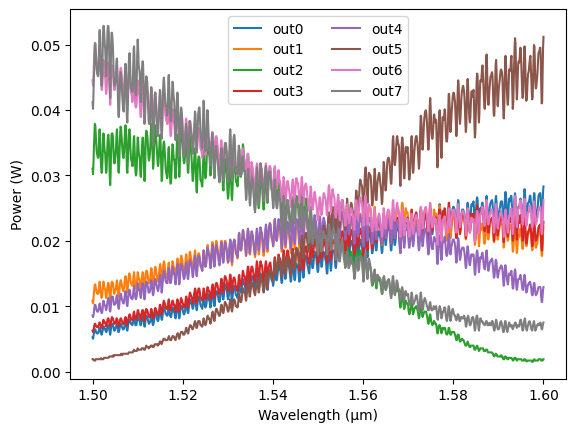

In [4]:
def load_sdict_npz(fname):
        d = np.load(fname)
        wls = d["wavelengths"]
        S = {}
        for k in d.files:
            if k == "wavelengths": continue
            # keys like "S_out3_in5"
            _, to_p, from_p = k.split("_", 2)
            S[(to_p, from_p)] = np.squeeze(d[k])
        return wls, S


w_i, Sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")
in_key  = "in7"
out_keys = ["out0","out1","out2","out3","out4","out5","out6","out7",]

# |S|^2 * Pin(mW) = Pout(mW); convert to µW
Pin_dBm = -10.2
for ok in out_keys:
    S = Sp[(ok, in_key)]                 
    P_uW = (np.abs(S)**2)    
    plt.plot(w_i, P_uW, label=ok)

plt.xlabel("Wavelength (µm)")
plt.ylabel("Power (W)")
plt.legend(ncol=2)
plt.show()